In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [2]:
# Load data
z2 = loadmat('z2.mat')['z2']
z2 = np.array(z2)

# Split data into inputs and outputs
X = z2[:, :6]
Y = z2[:, 6:]

# Normalize joint angles to be between -1 and 1
Y = Y / np.pi
print(Y)

# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

[[-0.5        -1.         -0.30769231 -0.5         1.         -0.25      ]
 [-0.5        -1.         -0.30769231 -0.5         1.         -0.21153846]
 [-0.5        -1.         -0.30769231 -0.5         1.         -0.17307692]
 ...
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.         -0.01923077]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.01923077]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.05769231]]


In [3]:
def train_validate_test_split(x, y, train_size=0.7, validate_size=0.15, test_size=0.15, random_state=None):
    if validate_size + test_size >= 1.0:
        raise ValueError("The sum of validate_size and test_size should be less than 1.0.")
    
    x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=train_size, random_state=random_state)
    
    remaining = 1.0 - train_size
    validate_ratio = validate_size / (validate_size + test_size)
    test_ratio = test_size / (validate_size + test_size)
    
    x_validate, x_test, y_validate, y_test = train_test_split(x_temp, y_temp, train_size=validate_ratio, test_size=test_ratio, random_state=random_state)
    
    return x_train, x_validate, x_test, y_train, y_validate, y_test

# Train-validate-test split
X_train, X_validate ,X_test, Y_train, Y_validate ,Y_test = train_validate_test_split(X, Y , train_size=0.7, validate_size=0.15, test_size=0.15, random_state=42)
# Create a fully connected neural network model
model = keras.Sequential([
        keras.layers.Dense(6),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        keras.layers.Dense(6)  # Output layer with 6 neurons (x, y, z, a, b, c)
])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("model_z22.h5", save_best_only=True, monitor='val_loss', mode='min')

# Learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])

# Train the model
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_validate, Y_validate),
                    batch_size=128, shuffle=True, callbacks=[early_stopping, model_checkpoint])

Epoch 1/1000
8388/8388 [==============================] - 135s 16ms/step - loss: 0.0257 - mean_squared_error: 0.0257 - val_loss: 0.0070 - val_mean_squared_error: 0.0070
Epoch 2/1000
8388/8388 [==============================] - 121s 14ms/step - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0063 - val_mean_squared_error: 0.0063
Epoch 3/1000
8388/8388 [==============================] - 129s 15ms/step - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0048 - val_mean_squared_error: 0.0048
Epoch 4/1000
8388/8388 [==============================] - 130s 16ms/step - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0046 - val_mean_squared_error: 0.0046
Epoch 5/1000
8388/8388 [==============================] - 129s 15ms/step - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0042 - val_mean_squared_error: 0.0042
Epoch 6/1000
8388/8388 [==============================] - 130s 15ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0035 - val_mean_squared_

Epoch 49/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.8072e-04 - mean_squared_error: 8.8072e-04 - val_loss: 0.0010 - val_mean_squared_error: 0.0010
Epoch 50/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.7558e-04 - mean_squared_error: 8.7558e-04 - val_loss: 0.0010 - val_mean_squared_error: 0.0010
Epoch 51/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.6880e-04 - mean_squared_error: 8.6880e-04 - val_loss: 0.0010 - val_mean_squared_error: 0.0010
Epoch 52/1000
8388/8388 [==============================] - 128s 15ms/step - loss: 8.6290e-04 - mean_squared_error: 8.6290e-04 - val_loss: 0.0010 - val_mean_squared_error: 0.0010
Epoch 53/1000
8388/8388 [==============================] - 128s 15ms/step - loss: 8.5862e-04 - mean_squared_error: 8.5862e-04 - val_loss: 0.0010 - val_mean_squared_error: 0.0010
Epoch 54/1000
8388/8388 [==============================] - 128s 15ms/step - loss: 8.5364e-04 - mean_squared_er

Epoch 95/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0395e-04 - mean_squared_error: 8.0395e-04 - val_loss: 9.9982e-04 - val_mean_squared_error: 9.9982e-04
Epoch 96/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0384e-04 - mean_squared_error: 8.0384e-04 - val_loss: 9.9997e-04 - val_mean_squared_error: 9.9997e-04
Epoch 97/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0368e-04 - mean_squared_error: 8.0368e-04 - val_loss: 0.0010 - val_mean_squared_error: 0.0010
Epoch 98/1000
8388/8388 [==============================] - 128s 15ms/step - loss: 8.0357e-04 - mean_squared_error: 8.0357e-04 - val_loss: 9.9969e-04 - val_mean_squared_error: 9.9969e-04
Epoch 99/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0351e-04 - mean_squared_error: 8.0351e-04 - val_loss: 9.9969e-04 - val_mean_squared_error: 9.9969e-04
Epoch 100/1000
8388/8388 [==============================] - 127s 15ms/step - l

Epoch 139/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0243e-04 - mean_squared_error: 8.0243e-04 - val_loss: 9.9935e-04 - val_mean_squared_error: 9.9935e-04
Epoch 140/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0243e-04 - mean_squared_error: 8.0243e-04 - val_loss: 9.9936e-04 - val_mean_squared_error: 9.9936e-04
Epoch 141/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0243e-04 - mean_squared_error: 8.0243e-04 - val_loss: 9.9935e-04 - val_mean_squared_error: 9.9935e-04
Epoch 142/1000
8388/8388 [==============================] - 126s 15ms/step - loss: 8.0243e-04 - mean_squared_error: 8.0243e-04 - val_loss: 9.9935e-04 - val_mean_squared_error: 9.9935e-04
Epoch 143/1000
8388/8388 [==============================] - 127s 15ms/step - loss: 8.0243e-04 - mean_squared_error: 8.0243e-04 - val_loss: 9.9935e-04 - val_mean_squared_error: 9.9935e-04
Epoch 144/1000
8388/8388 [==============================] - 127s 

In [4]:
# Evaluate the model on the test set
test_loss, _ = model.evaluate(X_test, Y_test)
print(f'Test Loss: {test_loss}')

7190/7190 [==============================] - 54s 8ms/step - loss: 9.9351e-04 - mean_squared_error: 9.9351e-04
Test Loss: 0.0009935108246281743


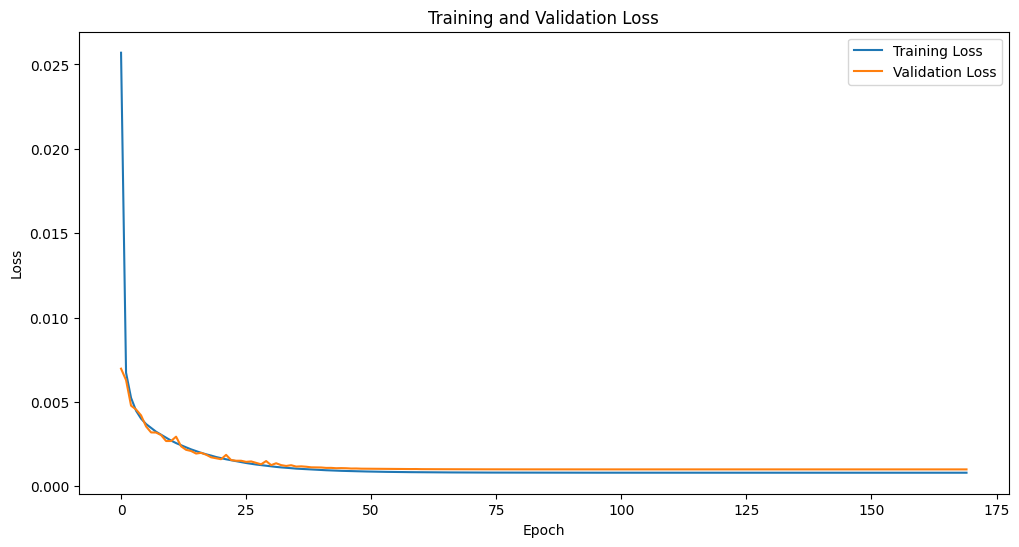

In [5]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

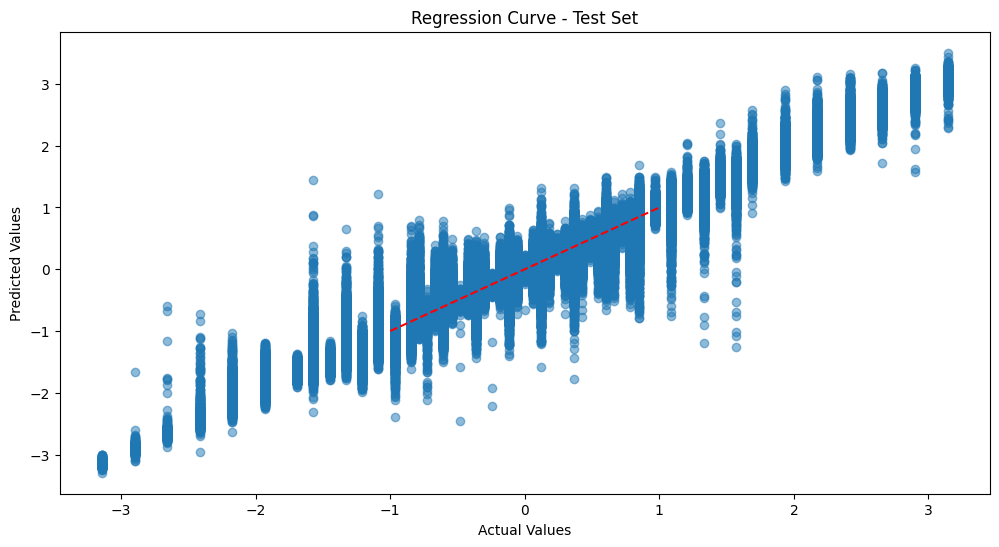

In [6]:
# Plot regression curve for test set
test_predictions = model.predict(X_test) * np.pi  # Use 'model' instead of 'best_model'
plt.figure(figsize=(12, 6))
plt.scatter(Y_test * np.pi, test_predictions, alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--')
plt.title('Regression Curve - Test Set')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

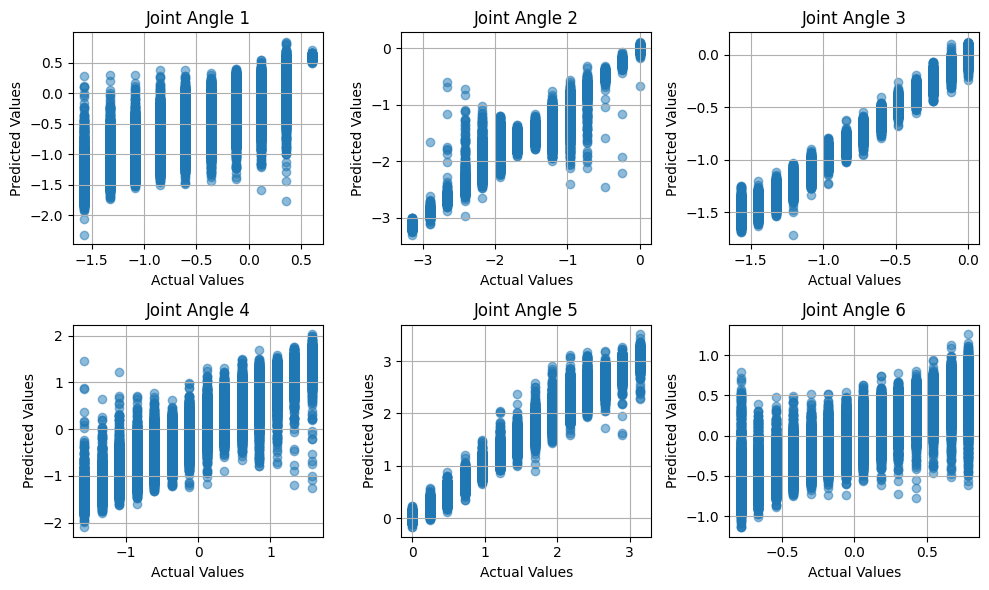

In [7]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Inverse normalize the joint angles for better interpretation
predictions = predictions * np.pi
Y_test = Y_test * np.pi
# Plotting predicted vs. actual values
plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    plt.scatter(Y_test[:, i], predictions[:, i], alpha=0.5)
    plt.title(f'Joint Angle {i + 1}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

plt.tight_layout()
plt.show()

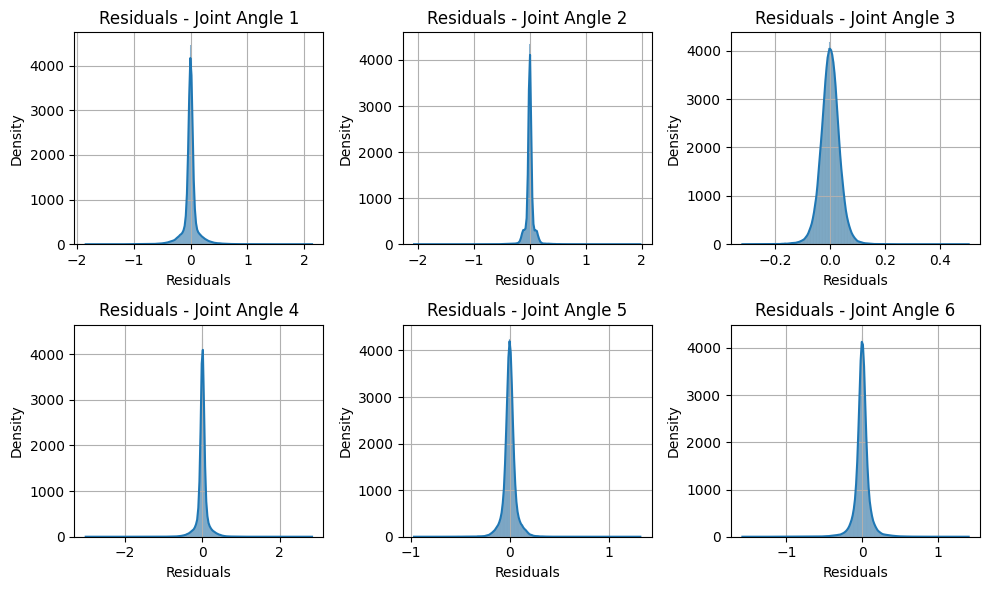

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Residual plots
residuals = Y_test - predictions

plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals - Joint Angle {i + 1}')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Load the best model for predictions
best_model = tf.keras.models.load_model("model_z2.h5")

# Test the loaded model with [10, 20, 30, 40, 50, 60]
test_inputs = np.array([[194.5, 161.4, 283.1, 0, -90, 38.07]])
predictions = best_model.predict(test_inputs) * np.pi

print("Predictions for test inputs:")
print(predictions)